In [2]:
import numpy as np
import glob
import torch
import torch.nn.functional as F

# Quick sanity check on a single file
test = np.load('/deck/users/mpiras/dataset/hsmr/HSMR-squat_butt_wink15.npy', allow_pickle=True)
print(test.shape)
print(test[0].keys())
print(test[0]['poses'].shape)

(75,)
dict_keys(['patch_cam_t', 'poses', 'betas', 'full_cam_t', 'bbx_cs'])
(1, 46)


In [3]:
import numpy as np
import glob

DATA_DIR = '/deck/users/mpiras/dataset/hsmr'

CLASS_PATTERNS = [
    ('butt_wink',          f'{DATA_DIR}/HSMR-squat_butt_wink*.npy'),
    ('depth_high',         f'{DATA_DIR}/HSMR-squat_depth_high*.npy'),
    ('hands_wide',         f'{DATA_DIR}/HSMR-squat_hands_wide*.npy'),
    ('head_position',      f'{DATA_DIR}/HSMR-squat_head_position*.npy'),
    ('high_heel',          f'{DATA_DIR}/HSMR-squat_high_heel*.npy'),
    ('no_errors',          f'{DATA_DIR}/HSMR-squat_no_errors*.npy'),
    ('rdl_hands_forward',  f'{DATA_DIR}/HSMR-rdl_hands_forward*.npy'),
    ('rdl_no_error',       f'{DATA_DIR}/HSMR-rdl_no_error*.npy'),
    ('rdl_too_much_depth', f'{DATA_DIR}/HSMR-rdl_too_much_depth*.npy'),
]
CLASS_NAMES = [name for name, _ in CLASS_PATTERNS]
NUM_CLASSES = len(CLASS_PATTERNS)

def load_files_with_filename(pattern):
    files = glob.glob(pattern)
    data_with_filename = []
    for file in files:
        arr = np.load(file, allow_pickle=True)
        for d in arr:
            d['filename'] = file
        data_with_filename.append(arr)
    print(f"  Loaded {len(files)} files: {pattern.split('/')[-1]}")
    return data_with_filename

print("Loading dataset...")
class_data = [load_files_with_filename(pattern) for _, pattern in CLASS_PATTERNS]

Loading dataset...
  Loaded 52 files: HSMR-squat_butt_wink*.npy
  Loaded 54 files: HSMR-squat_depth_high*.npy
  Loaded 52 files: HSMR-squat_hands_wide*.npy
  Loaded 50 files: HSMR-squat_head_position*.npy
  Loaded 51 files: HSMR-squat_high_heel*.npy
  Loaded 55 files: HSMR-squat_no_errors*.npy
  Loaded 54 files: HSMR-rdl_hands_forward*.npy
  Loaded 51 files: HSMR-rdl_no_error*.npy
  Loaded 51 files: HSMR-rdl_too_much_depth*.npy


In [4]:
dataset = []
for label, (samples, (name, _)) in enumerate(zip(class_data, CLASS_PATTERNS)):
    for sample in samples:
        tokens = [frame['poses'].flatten() for frame in sample]
        dataset.append({'tokens': tokens, 'label': label, 'filename': sample[0]['filename'], 'data': sample})

print(f"Total samples: {len(dataset)}")
for label, (name, _) in enumerate(CLASS_PATTERNS):
    count = sum(1 for s in dataset if s['label'] == label)
    print(f"  {label}: {name} — {count} samples")

Total samples: 470
  0: butt_wink — 52 samples
  1: depth_high — 54 samples
  2: hands_wide — 52 samples
  3: head_position — 50 samples
  4: high_heel — 51 samples
  5: no_errors — 55 samples
  6: rdl_hands_forward — 54 samples
  7: rdl_no_error — 51 samples
  8: rdl_too_much_depth — 51 samples


In [5]:
from sklearn.model_selection import train_test_split

max_seq_length = max(len(sample['tokens']) for sample in dataset)
print(f"Max sequence length: {max_seq_length}")
for sample in dataset:
    tokens = sample['tokens']
    if len(tokens) < max_seq_length:
        padding = [np.zeros_like(tokens[0]) for _ in range(max_seq_length - len(tokens))]
        sample['tokens'] = tokens + padding
    else:
        sample['tokens'] = tokens[:max_seq_length]

X = np.array([sample['tokens'] for sample in dataset])
y = np.array([sample['label'] for sample in dataset])
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Max sequence length: 75
Shape of X: (470, 75, 46), Shape of y: (470,)
Training set: (352, 75, 46), Test set: (118, 75, 46)


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=32, shuffle=False)

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        return self.fc(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

input_dim = X_train_tensor.shape[-1]
print(f"Input dim: {input_dim}, Seq len: {X_train_tensor.shape[1]}, Classes: {NUM_CLASSES}")

model = TransformerClassifier(input_dim, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        _, predicted = torch.max(model(X_batch), 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
print(f"\nTest Accuracy: {correct / total:.4f}")

Device: cuda
Input dim: 46, Seq len: 75, Classes: 9
Epoch 1/50, Loss: 1.9627
Epoch 2/50, Loss: 1.4821
Epoch 3/50, Loss: 0.9386
Epoch 4/50, Loss: 0.6410
Epoch 5/50, Loss: 0.5866
Epoch 6/50, Loss: 0.5256
Epoch 7/50, Loss: 0.4541
Epoch 8/50, Loss: 0.4437
Epoch 9/50, Loss: 0.3976
Epoch 10/50, Loss: 0.3461
Epoch 11/50, Loss: 0.2814
Epoch 12/50, Loss: 0.3042
Epoch 13/50, Loss: 0.3170
Epoch 14/50, Loss: 0.3354
Epoch 15/50, Loss: 0.2900
Epoch 16/50, Loss: 0.2284
Epoch 17/50, Loss: 0.2043
Epoch 18/50, Loss: 0.1528
Epoch 19/50, Loss: 0.1476
Epoch 20/50, Loss: 0.3358
Epoch 21/50, Loss: 0.3973
Epoch 22/50, Loss: 0.2237
Epoch 23/50, Loss: 0.1971
Epoch 24/50, Loss: 0.1192
Epoch 25/50, Loss: 0.0774
Epoch 26/50, Loss: 0.0817
Epoch 27/50, Loss: 0.0886
Epoch 28/50, Loss: 0.1042
Epoch 29/50, Loss: 0.0995
Epoch 30/50, Loss: 0.1536
Epoch 31/50, Loss: 0.4035
Epoch 32/50, Loss: 0.2144
Epoch 33/50, Loss: 0.1531
Epoch 34/50, Loss: 0.1458
Epoch 35/50, Loss: 0.2211
Epoch 36/50, Loss: 0.1121
Epoch 37/50, Loss: 0.

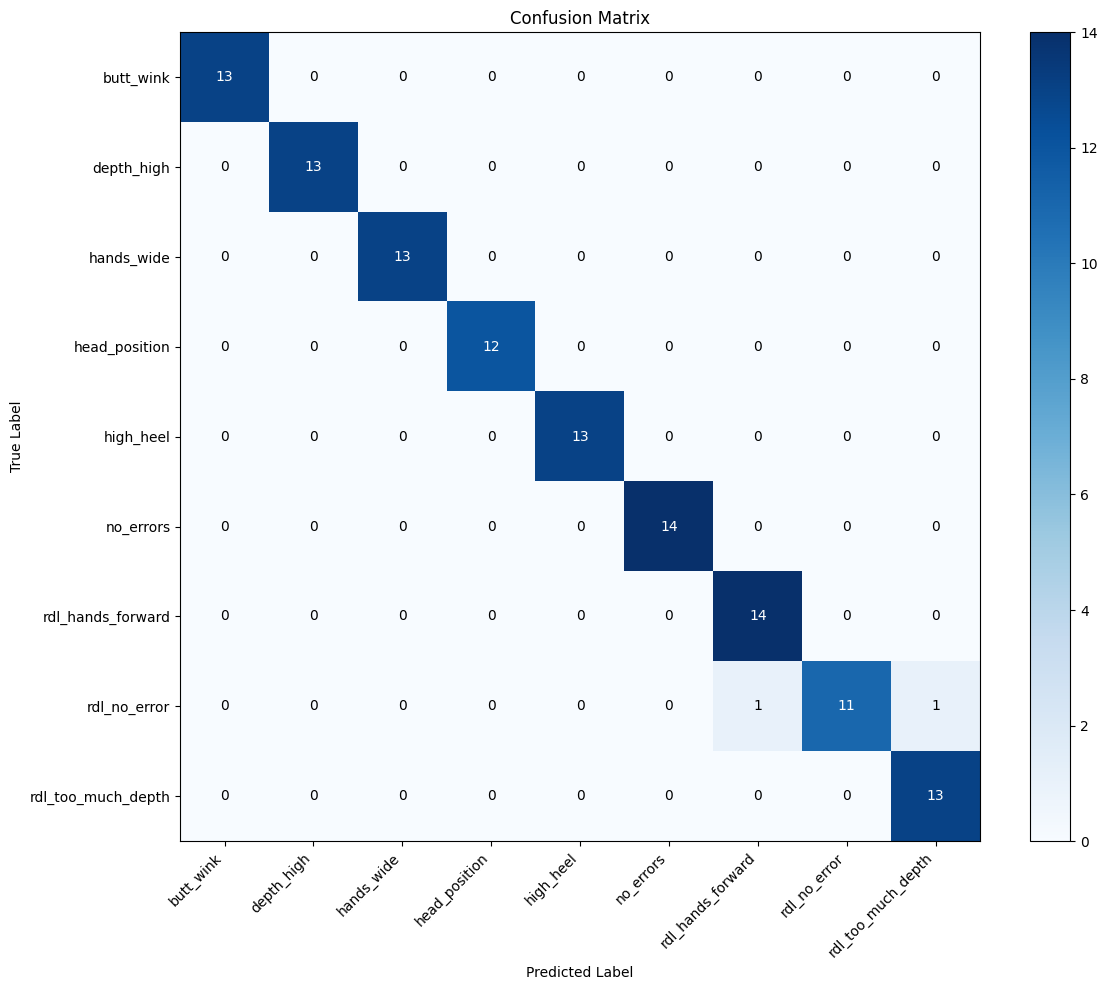


Classification Report:
                    precision    recall  f1-score   support

         butt_wink       1.00      1.00      1.00        13
        depth_high       1.00      1.00      1.00        13
        hands_wide       1.00      1.00      1.00        13
     head_position       1.00      1.00      1.00        12
         high_heel       1.00      1.00      1.00        13
         no_errors       1.00      1.00      1.00        14
 rdl_hands_forward       0.93      1.00      0.97        14
      rdl_no_error       1.00      0.85      0.92        13
rdl_too_much_depth       0.93      1.00      0.96        13

          accuracy                           0.98       118
         macro avg       0.98      0.98      0.98       118
      weighted avg       0.98      0.98      0.98       118



In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor.to(device))
    _, y_pred = torch.max(outputs, 1)
    y_pred = y_pred.cpu().numpy()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha='right')
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show(block=True)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

In [8]:
filenames_all = [sample['filename'] for sample in dataset]

all_indices = np.arange(len(dataset))
train_indices, test_indices = train_test_split(all_indices, test_size=0.25, random_state=42, stratify=y)
filenames_test = [filenames_all[i] for i in test_indices]

misclassified = y_pred != y_test
misclassified_filenames = [filenames_test[i] for i in range(len(y_test)) if misclassified[i]]
misclassified_true = y_test[misclassified]
misclassified_pred = y_pred[misclassified]

print(f"\n{'='*80}")
print(f"Misclassified Samples: {len(misclassified_filenames)}/{len(y_test)}")
print(f"{'='*80}")
for filename, true_label, pred_label in zip(misclassified_filenames, misclassified_true, misclassified_pred):
    print(f"File: {filename}")
    print(f"  True:      {CLASS_NAMES[true_label]}")
    print(f"  Predicted: {CLASS_NAMES[pred_label]}")
    print()


Misclassified Samples: 2/118
File: /deck/users/mpiras/dataset/hsmr/HSMR-rdl_no_error28.npy
  True:      rdl_no_error
  Predicted: rdl_hands_forward

File: /deck/users/mpiras/dataset/hsmr/HSMR-rdl_no_error1.npy
  True:      rdl_no_error
  Predicted: rdl_too_much_depth



Input sample shape: torch.Size([1, 75, 46])
Class: head_position
Video: /deck/users/mpiras/dataset/hsmr/HSMR-squat_head_position21.mp4


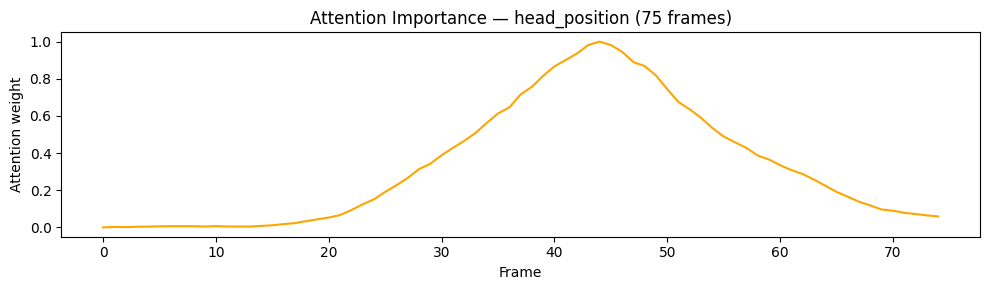

In [9]:
sample = dataset[180]
input_sample = torch.tensor(np.array(sample['tokens']), dtype=torch.float32).unsqueeze(0).to(device)
print(f"Input sample shape: {input_sample.shape}")
true_label = sample['label']
filename = sample['filename']
video_filename = filename.replace('.npy', '.mp4')
print(f"Class: {CLASS_NAMES[true_label]}")
print(f"Video: {video_filename}")

def get_attention_importance(model, x):
    model.eval()
    x_proj = model.input_projection(x)
    last_layer = model.transformer_encoder.layers[-1]
    _, attn_weights = last_layer.self_attn(x_proj, x_proj, x_proj, need_weights=True)
    global_importance = attn_weights.detach().cpu().numpy()[0].mean(axis=0)
    norm_importance = (global_importance - global_importance.min()) / \
                      (global_importance.max() - global_importance.min() + 1e-8)
    return norm_importance

attention_heatmap = get_attention_importance(model, input_sample)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(attention_heatmap, color='orange')
plt.title(f"Attention Importance — {CLASS_NAMES[true_label]} ({len(attention_heatmap)} frames)")
plt.xlabel("Frame")
plt.ylabel("Attention weight")
plt.tight_layout()
plt.show()

In [10]:
import cv2
import matplotlib.cm as cm

def color_video_with_attention(input_video_path, attention_scores, output_filename="hsmr_attention_result.mp4"):
    # 1. Setup Video Capture
    cap = cv2.VideoCapture(input_video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # 2. Setup Video Writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Alternative: *'avc1' or *'XVID'
    out = cv2.VideoWriter(output_filename, fourcc, fps, (width, height))
    
    # Use the JET colormap (Blue -> Yellow -> Red)
    colormap = cm.get_cmap('jet')
    
    # Ensure our attention scores match the video length
    if len(attention_scores) != total_frames:
        print(f"Error: Heatmap length ({len(attention_scores)}) must match video frames ({total_frames})")
        return

    print(f"Processing {total_frames} frames...")

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # 3. Get score for this exact frame
        score = attention_scores[frame_idx]
        
        # 4. Generate the "Heat" Overlay
        # Color from score (RGB)
        color_rgb = colormap(score)[:3]
        # Convert RGB to BGR for OpenCV (0-255 scale)
        color_bgr = (np.array(color_rgb[::-1]) * 255).astype(np.uint8)
        
        # Create a solid color mask
        mask = np.full_like(frame, color_bgr)
        
        # 5. Blend (add Weighted)
        # alpha controls the intensity of the "glow." Let's use 0.4 for subtlety.
        # We scale alpha by score so cold frames stay natural.
        alpha = score * 0.4
        result_frame = cv2.addWeighted(frame, 1 - alpha, mask, alpha, 0)
        
        # Optional: Burn in a label and score
        cv2.putText(result_frame, f"Frame: {frame_idx} | Attention: {score:.2f}", 
                    (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        
        # Write frame to the new file
        out.write(result_frame)
        frame_idx += 1

    # Cleanup
    cap.release()
    out.release()
    print(f"Video saved successfully as: {output_filename}")

# --- Execution ---
# Using 'video_filename' which you identified earlier (e.g., sample['filename'].replace('.npy', '.mp4'))
# 'attention_heatmap' is the 75-frame array from Step 1
color_video_with_attention(video_filename, attention_heatmap)

/tmp/ipykernel_2988599/3235874471.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('jet')


Processing 75 frames...
Video saved successfully as: hsmr_attention_result.mp4


In [11]:
def get_feature_saliency(model, input_tensor, target_class):
    model.eval()
    input_nodes = input_tensor.clone().detach().to(device)
    input_nodes.requires_grad_(True)
    output = model(input_nodes)
    score = output[0, target_class]
    model.zero_grad()
    score.backward()
    slc = input_nodes.grad.data.abs().squeeze().cpu().numpy()
    slc = (slc - slc.min()) / (slc.max() - slc.min() + 1e-8)
    return slc

feature_importance = get_feature_saliency(model, input_sample, true_label)
print(f"Saliency matrix shape: {feature_importance.shape}  (frames × features)")

Saliency matrix shape: (75, 46)  (frames × features)


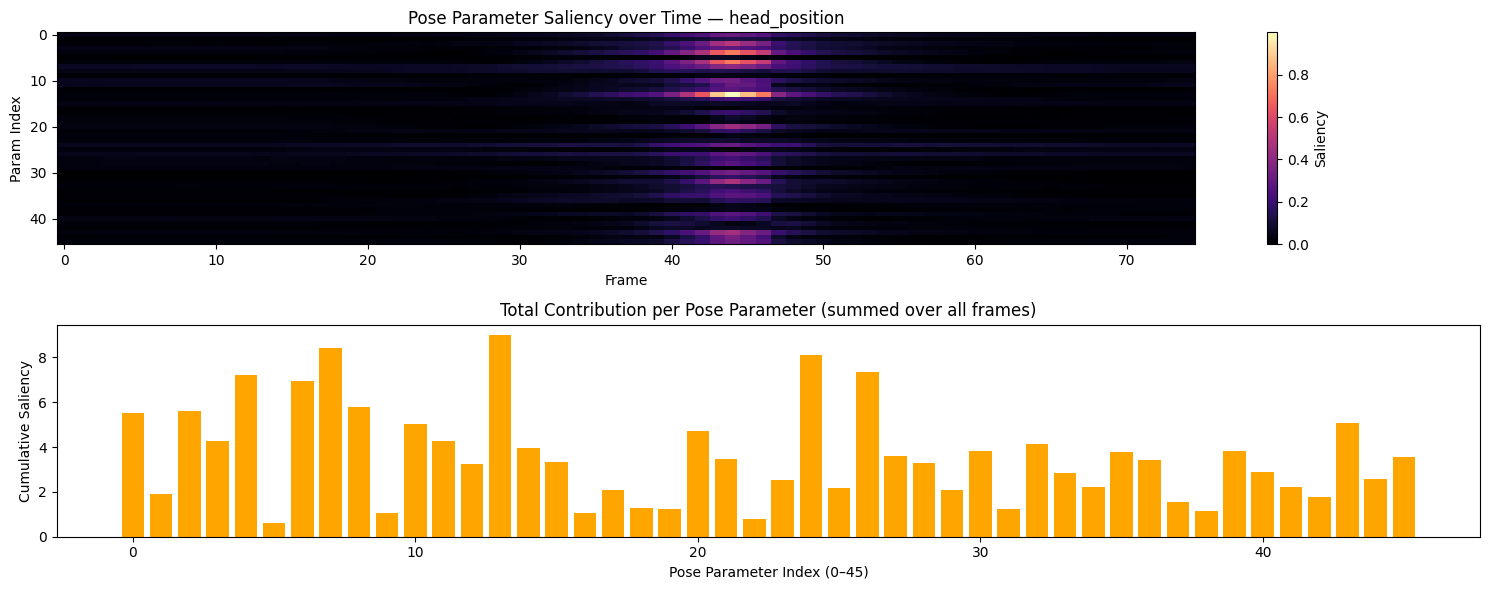

In [12]:
import matplotlib.pyplot as plt

global_feature_scores = feature_importance.sum(axis=0)
n_features = feature_importance.shape[1]

fig, axes = plt.subplots(2, 1, figsize=(15, 6))

im = axes[0].imshow(feature_importance.T, aspect='auto', cmap='magma', origin='upper')
axes[0].set_title(f"Pose Parameter Saliency over Time — {CLASS_NAMES[true_label]}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Param Index")
plt.colorbar(im, ax=axes[0], label='Saliency')

axes[1].bar(range(n_features), global_feature_scores, color='orange')
axes[1].set_title("Total Contribution per Pose Parameter (summed over all frames)")
axes[1].set_xlabel(f"Pose Parameter Index (0–{n_features-1})")
axes[1].set_ylabel("Cumulative Saliency")

plt.tight_layout()
plt.show()

In [13]:
saliency_matrix = get_feature_saliency(model, input_sample, true_label)

In [14]:
FULL_MAPPING = {
    0: "Pelvis Tilt",      1: "Pelvis List",       2: "Pelvis Rot",
    3: "R Hip Flexion",    4: "R Hip Adduction",   5: "R Hip Rotation",
    6: "R Knee Angle",     7: "R Ankle Angle",     8: "R Subtalar",
    9: "R MTP",           10: "L Hip Flexion",     11: "L Hip Adduction",
   12: "L Hip Rotation",  13: "L Knee Angle",      14: "L Ankle Angle",
   15: "L Subtalar",      16: "L MTP",             17: "Lumbar Bend",
   18: "Lumbar Ext",      19: "Lumbar Twist",      20: "Thorax Bend",
   21: "Thorax Ext",      22: "Thorax Twist",      23: "Head Bend",
   24: "Head Ext",        25: "Head Twist",         26: "R Scap Abd",
   27: "R Scap Elev",     28: "R Scap Up-Rot",     29: "R Shoulder X",
   30: "R Shoulder Y",    31: "R Shoulder Z",       32: "R Elbow Flex",
   33: "R Forearm Pro/Sup", 34: "R Wrist Flex",    35: "R Wrist Dev",
   36: "L Scap Abd",      37: "L Scap Elev",       38: "L Scap Up-Rot",
   39: "L Shoulder X",    40: "L Shoulder Y",       41: "L Shoulder Z",
   42: "L Elbow Flex",    43: "L Forearm Pro/Sup", 44: "L Wrist Flex",
   45: "L Wrist Dev",
}

N_FEATURES = 46
all_labels = [FULL_MAPPING[i] for i in range(N_FEATURES)]

def create_full_named_dashboard(video_path, saliency_matrix, output_path="full_anatomical_analysis.mp4"):
    from matplotlib.backends.backend_agg import FigureCanvasAgg
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.use('Agg')

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (1280, 960))

    print(f"Generating anatomical dashboard ({total_frames} frames)...")

    for i in range(min(total_frames, len(saliency_matrix))):
        ret, frame = cap.read()
        if not ret:
            break

        fig = plt.figure(figsize=(12.8, 9.6), dpi=100)

        ax1 = fig.add_subplot(2, 2, 1)
        ax1.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax1.set_title(f"Frame: {i}", fontweight='bold', fontsize=15)
        ax1.axis('off')

        ax2 = fig.add_axes([0.55, 0.05, 0.4, 0.9])
        current_saliency = saliency_matrix[i]
        y_pos = np.arange(N_FEATURES)
        ax2.barh(y_pos, current_saliency, color='#ff7f0e', align='center')
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(all_labels, fontsize=7)
        ax2.invert_yaxis()
        ax2.set_xlim(0, 1.1)
        ax2.set_xlabel("Saliency (Importance)", fontsize=10)
        ax2.set_title("Neural Focus: Pose Joints", fontsize=12)
        ax2.grid(axis='x', alpha=0.3)

        # Highlight high-saliency joints
        for tick_idx, tick_label in enumerate(ax2.get_yticklabels()):
            if current_saliency[tick_idx] > 0.4:
                tick_label.set_color('red')
                tick_label.set_weight('bold')

        canvas = FigureCanvasAgg(fig)
        canvas.draw()
        rgba_buffer = canvas.buffer_rgba()
        dashboard_rgb = np.asarray(rgba_buffer)[:, :, :3]
        out.write(cv2.cvtColor(dashboard_rgb, cv2.COLOR_RGB2BGR))
        plt.close(fig)

    cap.release()
    out.release()
    print(f"Analysis video saved: {output_path}")

create_full_named_dashboard(video_filename, saliency_matrix)

Generating anatomical dashboard (75 frames)...
Analysis video saved: full_anatomical_analysis.mp4
